### Подготовка данных

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
import optuna
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("movies-data.csv")
df.describe(include="all")

,Unnamed: 0,name,year,genre,country,duration,age_limit,budget,director,rating
count,2027.000000,2027,2027.000000,2027,2026,2023.000000,2027,1.254000e+03,1863,2027.000000
unique,NaN,2027,NaN,21,27,NaN,5,NaN,965,NaN
top,NaN,Человек-паук: Нет пути домой (2021),NaN,драма,США,NaN,16 +,NaN,Стивен Спилберг,NaN
freq,NaN,1,NaN,837,1314,NaN,820,NaN,20,NaN
mean,1039.474100,NaN,2004.373458,NaN,NaN,112.395452,NaN,6.438126e+07,NaN,6.862358
std,603.924499,NaN,15.146835,NaN,NaN,28.504114,NaN,5.893842e+07,NaN,0.910533
min,0.000000,NaN,1960.000000,NaN,NaN,7.000000,NaN,1.500000e+04,NaN,2.000000
25%,517.500000,NaN,1998.000000,NaN,NaN,97.000000,NaN,2.000000e+07,NaN,6.300000
50%,1036.000000,NaN,2010.000000,NaN,NaN,110.000000,NaN,4.425000e+07,NaN,6.900000
75%,1560.500000,NaN,2015.000000,NaN,NaN,126.000000,NaN,9.375000e+07,NaN,7.500000


In [5]:
df.head(10)

,Unnamed: 0,name,year,genre,country,duration,age_limit,budget,director,rating
0,0,Человек-паук: Нет пути домой (2021),2021,боевик,США,150.0,12 +,NaN,Джон Уоттс,8.2
1,1,Выживший (2015),2015,драма,США,156.0,18 +,135000000.0,Алехандро Гонсалес Иньярриту,8.0
2,2,Джентльмены (2019),2019,комедия,США,113.0,18 +,22000000.0,Гай Ричи,7.8
3,3,Гнев человеческий (2021),2021,триллер,США,118.0,18 +,NaN,Гай Ричи,7.1
4,4,Солнцепек (2021),2021,драма,Россия,NaN,18 +,NaN,NaN,4.6
5,6,1+1 (2011),2011,драма,Франция,112.0,16 +,NaN,NaN,8.5
6,7,Веном 2 (2021),2021,триллер,США,90.0,16 +,NaN,Энди Серкис,5.9
7,8,Зеленая книга (2018),2018,драма,США,130.0,18 +,NaN,Питер Фаррелли,8.2
8,9,Фантастические твари и где они обитают (2016),2016,приключения,США,133.0,12 +,180000000.0,Дэвид Йейтс,7.2
9,10,Марсианин (2015),2015,приключения,США,144.0,16 +,108000000.0,Ридли Скотт,8.0


**Нахождение нулевых значений**

In [6]:
df.isnull().sum()

Unnamed: 0      0
name            0
year            0
genre           0
country         1
duration        4
age_limit       0
budget        773
director      164
rating          0
dtype: int64

**Удаляю бюджет из-за большого отсутствия данных и название фильма, так как не влияет на рейтинг**

In [7]:
df = df.drop(columns=["Unnamed: 0", "budget", "name"])

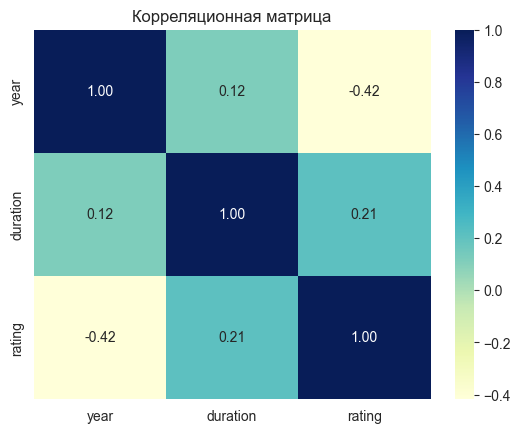

In [8]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Корреляционная матрица")
plt.show()

**Отсутствующую продолжительность заменяю на медианную**

In [9]:
df["duration"].fillna(df["duration"].median(), inplace=True)

/var/folders/tv/lm7074195838_v8w7hj_jm_m0000gn/T/ipykernel_1452/3572065478.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["duration"].fillna(df["duration"].median(), inplace=True)


**Возрастная категория становится числом**

In [10]:
ages = {
    "0 +": 0,
    "6 +": 6,
    "12 +": 12,
    "16 +": 16,
    "18 +": 18,
}
df["age_limit"] = df["age_limit"].map(ages)

**Отсутсвующие страны заменяю на самые популярные. Оставляю только страны у которых больше 10 фильмов в датасете, остальные Other. Преобразую с помощью One-Hot Encoding**

In [11]:
df["country"].fillna(df["country"].mode()[0], inplace=True)

counties_counts = df["country"].value_counts()
idx = counties_counts[counties_counts < 10].index
df["country"] = df["country"].replace(idx, "Other")

df = pd.get_dummies(df, columns=["country"])

/var/folders/tv/lm7074195838_v8w7hj_jm_m0000gn/T/ipykernel_1452/2481428141.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["country"].fillna(df["country"].mode()[0], inplace=True)


**Оставляю только жанр, который встречается больше 10 раз в датасете, остальные Other. Преобразую с помощью One-Hot Encoding**

In [12]:
genre_counts = df["genre"].value_counts()
idx = genre_counts[genre_counts < 10].index
df["genre"] = df["genre"].replace(idx, "Other")

df = pd.get_dummies(df, columns=["genre"])

**Остаются режисеры у которых больше трех фильмов в датасете. Остальные и нулевые заменяются на Other. Для режисеров был выбран Target Encoding**

In [13]:
directors = df["director"].value_counts()
idx = directors[directors < 3].index
df["director"] = df["director"].replace(idx, "Other")
df["director"].fillna("Other", inplace=True)

dir_mean_ranting = df.groupby("director")["rating"].mean()
df["dir_mean_rainting"] = df["director"].map(dir_mean_ranting)

df = df.drop(columns=["director"])

/var/folders/tv/lm7074195838_v8w7hj_jm_m0000gn/T/ipykernel_1452/917978385.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["director"].fillna("Other", inplace=True)


### PCA

In [14]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [16]:
df

,year,duration,age_limit,rating,country_Other,country_Великобритания,country_Германия,country_Индия,country_Испания,country_Италия,...,genre_детский,genre_драма,genre_комедия,genre_короткометражный,genre_мелодрама,genre_мультфильмы,genre_приключения,genre_триллер,genre_ужасы,dir_mean_rainting
0,2021,150.0,12,8.2,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,7.666667
1,2015,156.0,18,8.0,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,6.741826
2,2019,113.0,18,7.8,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,7.225000
3,2021,118.0,18,7.1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,7.225000
4,2021,110.0,18,4.6,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,6.741826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022,2015,86.0,16,3.2,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,4.033333
2023,2015,93.0,16,5.2,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,6.741826
2024,2014,90.0,18,3.5,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,6.741826
2025,2014,128.0,16,7.0,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,6.741826


### Выбросы

<function matplotlib.pyplot.show(close=None, block=None)>

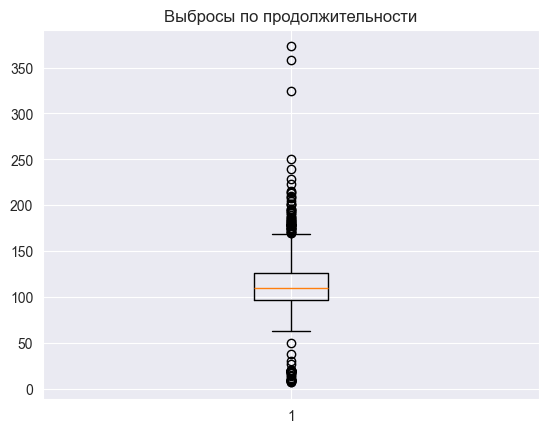

In [214]:
plt.boxplot(df["duration"])
plt.title("Выбросы по продолжительности")
plt.show

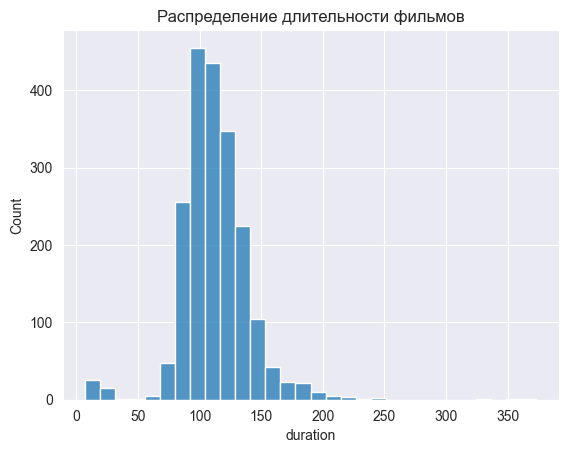

In [215]:
sns.histplot(df["duration"], bins=30)
plt.title("Распределение длительности фильмов")
plt.show()

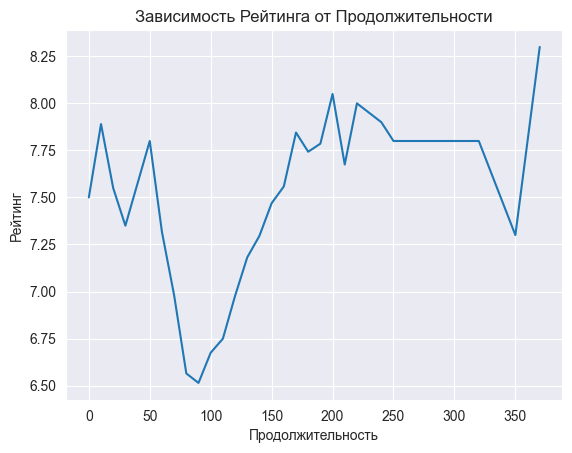

In [216]:
group_duration = (df["duration"] // 10) * 10
df.groupby(group_duration)["rating"].mean().plot()
plt.title("Зависимость Рейтинга от Продолжительности")
plt.xlabel("Продолжительность")
plt.ylabel("Рейтинг")
plt.show()

*Выбросы оствил, так как они не являются ошибкой и влияют на рейтинг*

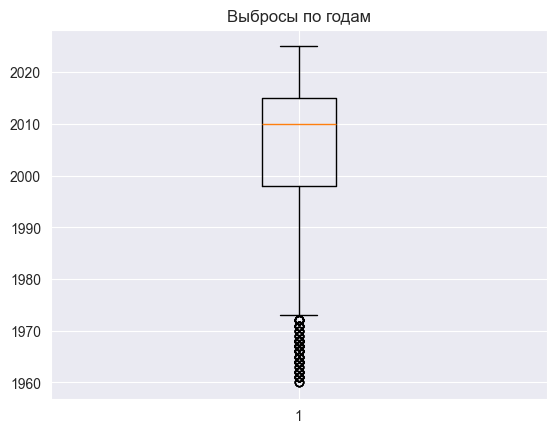

In [217]:
plt.boxplot(df["year"])
plt.title("Выбросы по годам")
plt.show()

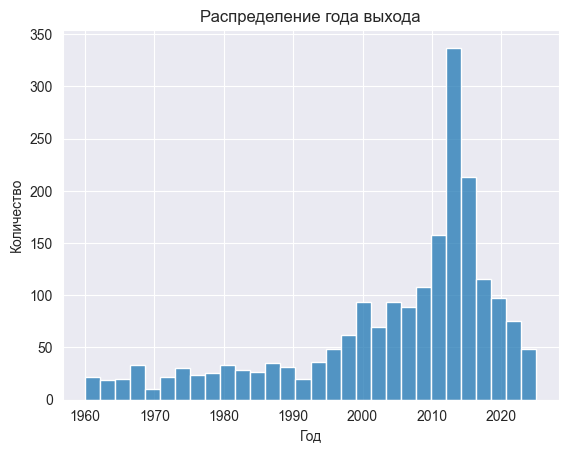

In [218]:
sns.histplot(df["year"], bins=30)
plt.title("Распределение года выхода")
plt.xlabel("Год")
plt.ylabel("Количество")
plt.show()

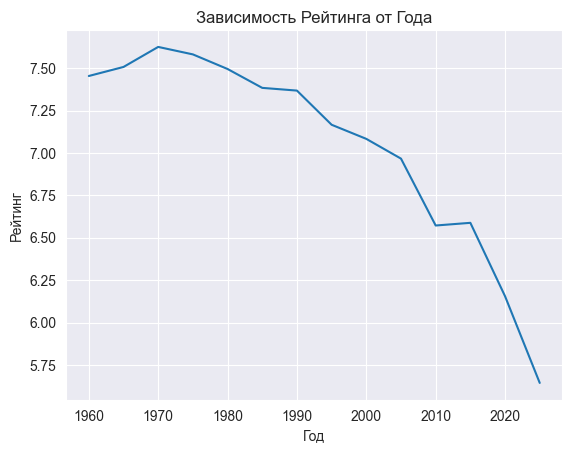

In [219]:
group_year = (df["year"] // 5) * 5
df.groupby(group_year)["rating"].mean().plot()
plt.title("Зависимость Рейтинга от Года")
plt.xlabel("Год")
plt.ylabel("Рейтинг")
plt.show()

*Выбросы по годам есть, но они так же не являются ошибками и не в большом количестве и имеют влияние на рейтинг*

### Группировка данных

In [220]:
x = df.drop(columns=["rating"])
y = df["rating"]

x_train_val, x_test, y_train_val, y_test = train_test_split(x, y, test_size=0.25, random_state=1)
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.25, random_state=1)

### Baseline решение

In [221]:
baseline_val = y_train.mean()

### Проверка baseline

In [222]:
y_baseline = []
for i in range(len(x_test)):
    y_baseline.append(baseline_val)
    
mae_baseline = mean_absolute_error(y_test, y_baseline)
mse_baseline = mean_squared_error(y_test, y_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_baseline))

In [223]:
print("MAE Baseline =", round(mae_baseline, 2))
print("MSE Baseline =", round(mse_baseline, 2))
print("RMSE Baseline =", round(rmse_baseline, 2))

MAE Baseline = 0.72
MSE Baseline = 0.83
RMSE Baseline = 0.91


### Дерево решений в sklearn

In [224]:
tree = DecisionTreeRegressor(random_state=1)
tree.fit(x_train, y_train)

y_sklearn = tree.predict(x_test)

mae_sklearn = mean_absolute_error(y_test, y_sklearn)
mse_sklearn = mean_absolute_error(y_test, y_sklearn)
rmse_sklearn = np.sqrt(mean_absolute_error(y_test, y_sklearn))

In [225]:
print("MAE Sklearn =", round(mae_sklearn, 2))
print("MAE Sklearn =", round(mse_sklearn, 2))
print("RMSE Sklearn =", round(rmse_sklearn, 2))

MAE Sklearn = 0.74
MAE Sklearn = 0.74
RMSE Sklearn = 0.86


**Гиперпараметры**

In [226]:
def objective_params_sklearn(trial):
    max_depth = trial.suggest_int("max_depth", 1, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 15)

    tree = DecisionTreeRegressor(max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=1)

    tree.fit(x_train, y_train)

    y_pred_val = tree.predict(x_val)

    return np.sqrt(mean_squared_error(y_val, y_pred_val))

In [227]:
study_sklearn = optuna.create_study(direction="minimize")
study_sklearn.optimize(objective_params_sklearn, n_trials=100, show_progress_bar=True)

sklearn_best_max_depth = study_sklearn.best_params["max_depth"]
sklearn_best_min_samples_leaf = study_sklearn.best_params["min_samples_leaf"]

[I 2025-10-19 17:28:32,321] A new study created in memory with name: no-name-0e2ae261-99f7-46b9-831c-da329304a257


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-10-19 17:28:32,340] Trial 0 finished with value: 0.8439395606377931 and parameters: {'max_depth': 1, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.8439395606377931.
[I 2025-10-19 17:28:32,344] Trial 1 finished with value: 0.7102682907777488 and parameters: {'max_depth': 4, 'min_samples_leaf': 15}. Best is trial 1 with value: 0.7102682907777488.
[I 2025-10-19 17:28:32,349] Trial 2 finished with value: 0.8439395606377931 and parameters: {'max_depth': 1, 'min_samples_leaf': 6}. Best is trial 1 with value: 0.7102682907777488.
[I 2025-10-19 17:28:32,354] Trial 3 finished with value: 0.6892195584229269 and parameters: {'max_depth': 7, 'min_samples_leaf': 10}. Best is trial 3 with value: 0.6892195584229269.
[I 2025-10-19 17:28:32,360] Trial 4 finished with value: 0.6992666646488136 and parameters: {'max_depth': 9, 'min_samples_leaf': 4}. Best is trial 3 with value: 0.6892195584229269.
[I 2025-10-19 17:28:32,363] Trial 5 finished with value: 0.7004384504623741 and parameters: {

In [228]:
print(study_sklearn.best_params)

{'max_depth': 7, 'min_samples_leaf': 7}


**Сравнение тренировочной и валидационной метрики**

In [229]:
tree = DecisionTreeRegressor(max_depth=sklearn_best_max_depth, min_samples_leaf=sklearn_best_min_samples_leaf, random_state=1)

tree.fit(x_train, y_train)

y_pred_train = tree.predict(x_train)
y_pred_val = tree.predict(x_val)

mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_val = mean_absolute_error(y_val, y_pred_val)
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))

In [231]:
print("MAE Train =", round(mae_train, 2))
print("MAE Val =", round(mae_val, 2))
print("RMSE Train =", round(rmse_train, 2))
print("RMSE Val =", round(rmse_val, 2))

MAE Train = 0.49
MAE Val = 0.53
RMSE Train = 0.63
RMSE Val = 0.68


**На лучших гипермараметрах:**

In [232]:
tree = DecisionTreeRegressor(max_depth=sklearn_best_max_depth, min_samples_leaf=sklearn_best_min_samples_leaf, random_state=1)
tree.fit(x_train, y_train)

y_sklearn = tree.predict(x_test)

mae_sklearn = mean_absolute_error(y_test, y_sklearn)
mse_sklearn = mean_squared_error(y_test, y_sklearn)
rmse_sklearn = np.sqrt(mean_squared_error(y_test, y_sklearn))

In [233]:
print("MAE Sklearn =", round(mae_sklearn, 2))
print("MSE Sklearn =", round(mse_sklearn, 2))
print("RMSE Sklearn =", round(rmse_sklearn, 2))

MAE Sklearn = 0.56
MSE Sklearn = 0.55
RMSE Sklearn = 0.74


### Реализация дерева решений

In [234]:
class Node:
    def __init__(self, feature=None, threshold=None, left_subtree=None, right_subtree=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left_subtree = left_subtree
        self.right_subtree = right_subtree
        self.value = value


class MyDecisionTreeRegressor:
    def __init__(self, max_depth, min_samples_leaf):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.tree = None

    def _mse(self, y):
        return np.mean((y - y.mean()) ** 2)

    def _gini(self, y, left_y, right_y):
        return self._mse(y) - (self._mse(left_y) * len(left_y) + self._mse(right_y) * len(right_y))
    
    def _best_split(self, x, y):
        feature, threshold = None, None
        max_gini = -np.inf
        for ftr in x.columns:
            uniq_x = np.unique(x[ftr])
            for i in range(len(uniq_x) - 1):
                thr = (uniq_x[i] + uniq_x[i + 1]) / 2
                left_x_idx = x[x[ftr] <= thr].index
                right_x_idx = x[x[ftr] > thr].index
                if len(left_x_idx) <= self.min_samples_leaf or len(right_x_idx) <= self.min_samples_leaf:
                    continue

                left_target = y.loc[left_x_idx]
                right_target = y.loc[right_x_idx]

                if self._gini(y, left_target, right_target) >= max_gini:
                    max_gini = self._gini(y, left_target, right_target)
                    feature = ftr
                    threshold = thr

        return feature, threshold

    def _build_tree(self, x, y, depth=0):
        if depth == self.max_depth:
            return Node(value=np.mean(y))

        feature, threshold = self._best_split(x, y)
        
        if feature is None or threshold is None:
            return Node(value=np.mean(y))
        
        left_x_idx = x[x[feature] <= threshold].index
        right_x_idx = x[x[feature] > threshold].index
        
        left_x = x.loc[left_x_idx]
        right_x = x.loc[right_x_idx]

        left_target = y.loc[left_x_idx]
        right_target = y.loc[right_x_idx]

        left_subtree = self._build_tree(left_x, left_target, depth + 1)
        right_subtree = self._build_tree(right_x, right_target, depth + 1)

        return Node(feature=feature, threshold=threshold, left_subtree=left_subtree, right_subtree=right_subtree, value=np.mean(y))
    
    def fit(self, x, y):
        self.tree = self._build_tree(x, y, 0)
        return self

    def predict(self, x):
        predict_targets = []
        for _, row in x.iterrows():
            node = self.tree
            while node.left_subtree is not None and node.right_subtree is not None:
                if row[node.feature] <= node.threshold:
                    node = node.left_subtree
                else:
                    node = node.right_subtree
            predict_targets.append(node.value)
            
        return predict_targets

**Подбор гиперпараметров**

In [235]:
def objective_params_mytree(trial):
    max_depth = trial.suggest_int("max_depth", 1, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 15)

    tree = MyDecisionTreeRegressor(max_depth=max_depth, min_samples_leaf=min_samples_leaf)
    tree.fit(x_train, y_train)
    y_pred_val = tree.predict(x_val)

    return np.sqrt(mean_squared_error(y_val, y_pred_val))

In [236]:
study_mytree = optuna.create_study(direction="minimize")
study_mytree.optimize(objective_params_mytree, n_trials=100, show_progress_bar=True)

mytree_best_max_depth = study_mytree.best_params["max_depth"]
mytree_best_min_samples_leaf = study_mytree.best_params["min_samples_leaf"]

[I 2025-10-19 17:28:57,977] A new study created in memory with name: no-name-f09932bc-8642-4c56-b17a-a80124ff6485


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-10-19 17:28:59,553] Trial 0 finished with value: 0.7046120925531919 and parameters: {'max_depth': 5, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.7046120925531919.
[I 2025-10-19 17:29:02,027] Trial 1 finished with value: 0.6871640926195091 and parameters: {'max_depth': 8, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.6871640926195091.
[I 2025-10-19 17:29:03,824] Trial 2 finished with value: 0.6892195584229269 and parameters: {'max_depth': 7, 'min_samples_leaf': 9}. Best is trial 1 with value: 0.6871640926195091.
[I 2025-10-19 17:29:03,984] Trial 3 finished with value: 0.8439395606377931 and parameters: {'max_depth': 1, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.6871640926195091.
[I 2025-10-19 17:29:04,340] Trial 4 finished with value: 0.7851309746783133 and parameters: {'max_depth': 2, 'min_samples_leaf': 13}. Best is trial 1 with value: 0.6871640926195091.
[I 2025-10-19 17:29:06,071] Trial 5 finished with value: 0.6955586778405869 and parameters: {'

In [238]:
print(study_mytree.best_params)

{'max_depth': 9, 'min_samples_leaf': 11}


In [239]:
tree = MyDecisionTreeRegressor(max_depth=mytree_best_max_depth, min_samples_leaf=mytree_best_min_samples_leaf)
tree.fit(x_train, y_train)

y_mytree = tree.predict(x_test)

mae_mytree = mean_absolute_error(y_test, y_mytree)
mse_mytree = mean_squared_error(y_test, y_mytree)
rmse_mytree = np.sqrt(mean_squared_error(y_test, y_mytree))

In [240]:
print("MAE =", round(mae_mytree, 2))
print("MSE =", round(mse_mytree, 2))
print("RMSE =", round(rmse_mytree, 2))

MAE = 0.56
MSE = 0.53
RMSE = 0.73


### Разница ошибок sklear и моей реализации

In [241]:
print("Разница MAE =", abs(mae_sklearn - mae_mytree))
print("Разница MSE =", abs(mse_sklearn - mse_mytree))
print("Разница RMSE =", abs(rmse_sklearn - rmse_mytree))

Разница MAE = 0.00875380481492094
Разница MSE = 0.011366770542110216
Разница RMSE = 0.007738898720606624
